# SCAN Dataset Exploration

This notebook validates that the SCAN dataset and PyTorch DataLoader all work correctly.

## Dataset Exploration

In [ ]:
import sys
sys.path.append('../') 
from data.dataset import SCANDataset
from transformers import T5Tokenizer
from torch.utils.data import DataLoader

In [10]:
# Configuration
from transformers import T5Tokenizer
tokenizer = T5Tokenizer.from_pretrained('t5-small')
batch_size = 32

In [11]:
# Load training data
from data.dataset import SCANDataset

dataset = SCANDataset(
    filepath='../data/scan/simple_split/tasks_train_simple.txt',
    tokenizer=tokenizer
)

print(f"Dataset size: {len(dataset)}")
input_ids, output_ids, _, _ = dataset[0]
print(f"Sample input: {tokenizer.decode(input_ids, skip_special_tokens=True)}")
print(f"Sample output: {tokenizer.decode(output_ids, skip_special_tokens=True)}")

Loading examples from ../data/scan/simple_split/tasks_train_simple.txt...
Dataset size: 16728
Sample input: jump opposite right twice and turn opposite right thrice
Sample output: I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_TURN_RIGHT I_TURN_


### Dataset Statistics

Output length - min: 5, max: 50, avg: 44.8


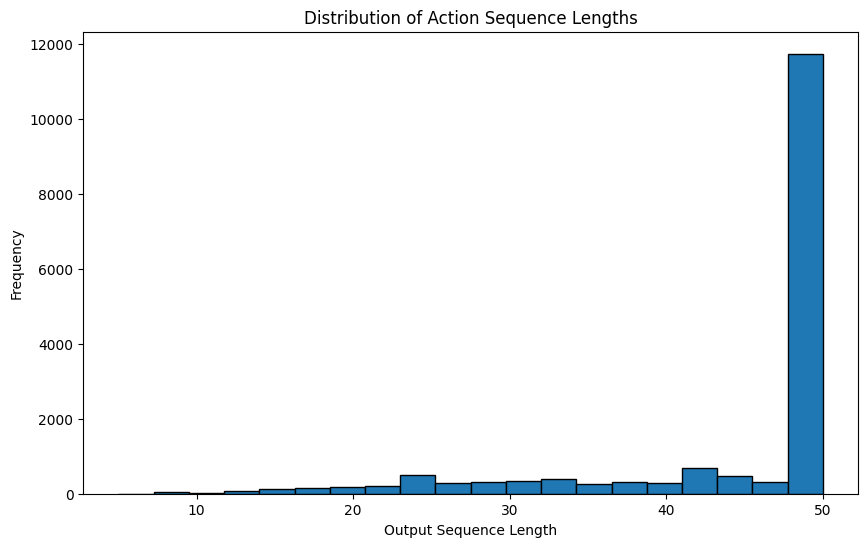

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate statistics
lengths = []
for i in range(len(dataset)):
    _, output_ids, _, _ = dataset[i]
    length = (output_ids != 0).sum().item()
    lengths.append(length)

print(f"Output length - min: {min(lengths)}, max: {max(lengths)}, avg: {sum(lengths)/len(lengths):.1f}")

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=20, edgecolor='black')
plt.xlabel('Output Sequence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Action Sequence Lengths')
plt.show()